## Step 1: Loading and Previewing the Dataset

We begin by importing necessary libraries and loading the dataset from the data folder.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Aviation_Data.csv', low_memory=False)

df.head()

Matplotlib is building the font cache; this may take a moment.


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [4]:
df.shape

(90348, 31)

In [5]:
df.columns          # Column names (Index object)

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [6]:
df.index            # Row indices

RangeIndex(start=0, stop=90348, step=1)

In [7]:
df.dtypes              # Data type of each column

Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object
Report.Status 

In [8]:
df.info()              # Non-null counts and types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90348 entries, 0 to 90347
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      90348 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [9]:
df.isnull().sum()                     # Nulls per column

Event.Id                   1459
Investigation.Type            0
Accident.Number            1459
Event.Date                 1459
Location                   1511
Country                    1685
Latitude                  55966
Longitude                 55975
Airport.Code              40216
Airport.Name              37644
Injury.Severity            2459
Aircraft.damage            4653
Aircraft.Category         58061
Registration.Number        2841
Make                       1522
Model                      1551
Amateur.Built              1561
Number.of.Engines          7543
Engine.Type                8555
FAR.Description           58325
Schedule                  77766
Purpose.of.flight          7651
Air.carrier               73700
Total.Fatal.Injuries      12860
Total.Serious.Injuries    13969
Total.Minor.Injuries      13392
Total.Uninjured            7371
Weather.Condition          5951
Broad.phase.of.flight     28624
Report.Status              7843
Publication.Date          16689
dtype: i

In [10]:
df[df.isnull().any(axis=1)]          # Rows with any nulls

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90343,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
90344,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
90345,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
90346,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [11]:
display(df.describe(include='all').transpose())
print("\nData Types:\n", df.dtypes)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Event.Id,88889,87951,20001212X19172,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investigation.Type,90348,71,Accident,85015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accident.Number,88889,88863,CEN22LA149,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event.Date,88889,14782,1984-06-30,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,88837,27758,"ANCHORAGE, AK",434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,88663,219,United States,82248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,34382,25589,332739N,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,34373,27154,0112457W,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport.Code,50132,10374,NONE,1488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport.Name,52704,24870,Private,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Data Types:
 Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object


In [12]:
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
numeric_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Step 2: Data Cleaning

Here, we handle missing values, convert column data types, and remove irrelevant or duplicate entries.


In [13]:
#Handle missing data
df.dropna(subset=['Event.Date'], inplace=True)
df.fillna(0, inplace=True)

In [14]:
#Handling missing values
print("Missing values:\n", df[numeric_cols].isnull().sum())
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

Missing values:
 Total.Fatal.Injuries      0
Total.Serious.Injuries    0
Total.Minor.Injuries      0
Total.Uninjured           0
dtype: int64


In [15]:
# STEP 4: Outlier removal (IQR method)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

for col in numeric_cols:
    df = remove_outliers(df, col)

In [16]:
df.duplicated().value_counts()

False    42242
Name: count, dtype: int64

In [17]:
df = df.drop_duplicates()
df.shape

(42242, 31)

## Step 3: Exploratory Data Analysis (EDA)

Explore accident distribution by year, aircraft type, and injury severity.


In [18]:
# Ensure Event.Date is in datetime format
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')

In [19]:
# Drop rows where date is missing
df = df.dropna(subset=['Event.Date'])

In [20]:
# Extract year from Event.Date
df['event_year'] = df['Event.Date'].dt.year

In [21]:
# Yearly accident counts
accident_by_year = df['event_year'].value_counts().sort_index()


## Step 4: Visualizations

Using visual tools to understand high-risk aircraft types and patterns in accident causes or severity.


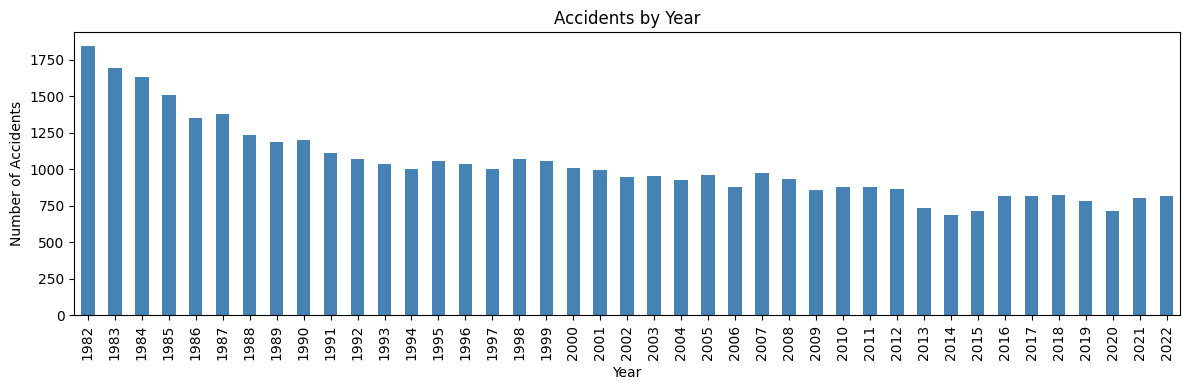

In [22]:
# Plot yearly accidents
plt.figure(figsize=(12, 4))
accident_by_year.plot(kind='bar', color='steelblue')
plt.title('Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()


In [31]:
# Saving the plot above
plt.savefig("accidents_by_year.png", dpi=300, bbox_inches='tight')  # Save image to file
plt.show()

<Figure size 640x480 with 0 Axes>

In [24]:
# Load your CSV file
import pandas as pd
df = pd.read_csv('Aviation_Data.csv')

# Converting Event.Date to datetime
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')

# Fill injury columns with zeros for NA
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
df[injury_cols] = df[injury_cols].fillna(0)

# Filter out rows without Make or Model
df = df.dropna(subset=['Make', 'Model'])

/var/folders/4d/l1rvjvyx671bkxht55gt0x1w0000gn/T/ipykernel_70562/2933292338.py:3: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Aviation_Data.csv')


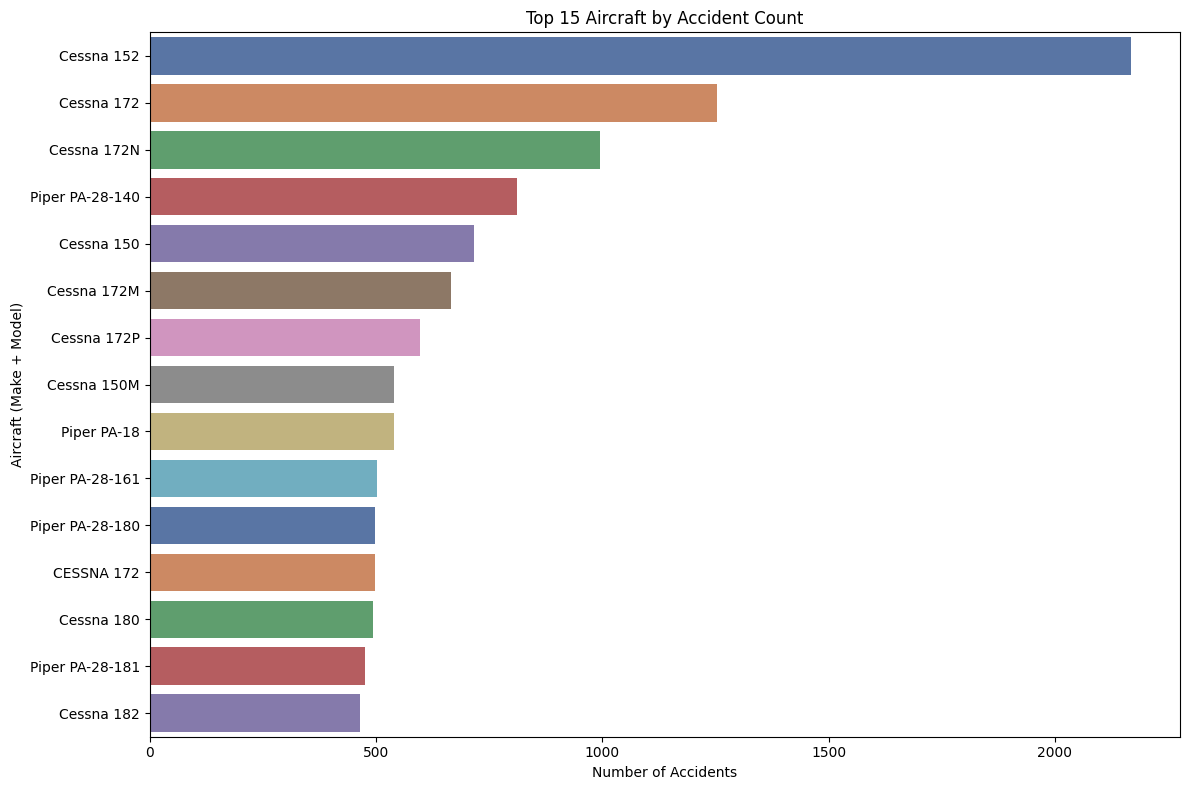

In [25]:
## Accident Count by Aircraft Make + Model (Top 15 most frequent aircraft only)
# Combine Make and Model for visualization
df['Make_Model'] = df['Make'] + ' ' + df['Model']

# Get top 15 most common aircraft (Make + Model)
top_15_aircraft = df['Make_Model'].value_counts().nlargest(15).index

# Filtering the dataset to include only top 15 aircraft
df_filtered = df[df['Make_Model'].isin(top_15_aircraft)]

# Summarize accident counts for top 15
accident_summary = df_filtered['Make_Model'].value_counts().reset_index()
accident_summary.columns = ['Make_Model', 'Accident Count']

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=accident_summary,
    y='Make_Model',
    x='Accident Count',
    hue='Make_Model',         
    palette='deep',
    legend=False              
)

plt.title('Top 15 Aircraft by Accident Count')
plt.xlabel('Number of Accidents')
plt.ylabel('Aircraft (Make + Model)')
plt.tight_layout()
plt.show()

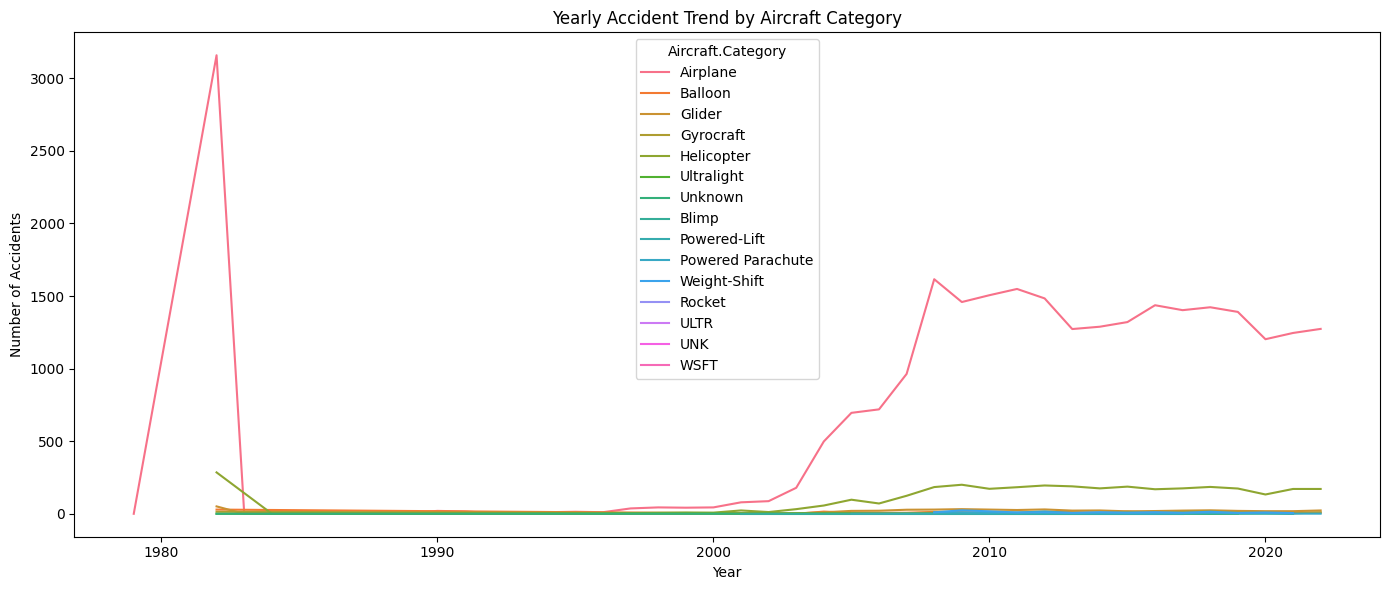

In [26]:

df['Year'] = df['Event.Date'].dt.year
yearly_trend = df.groupby(['Year', 'Aircraft.Category']).size().reset_index(name='Accident Count')

plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_trend, x='Year', y='Accident Count', hue='Aircraft.Category')
plt.title('Yearly Accident Trend by Aircraft Category')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()

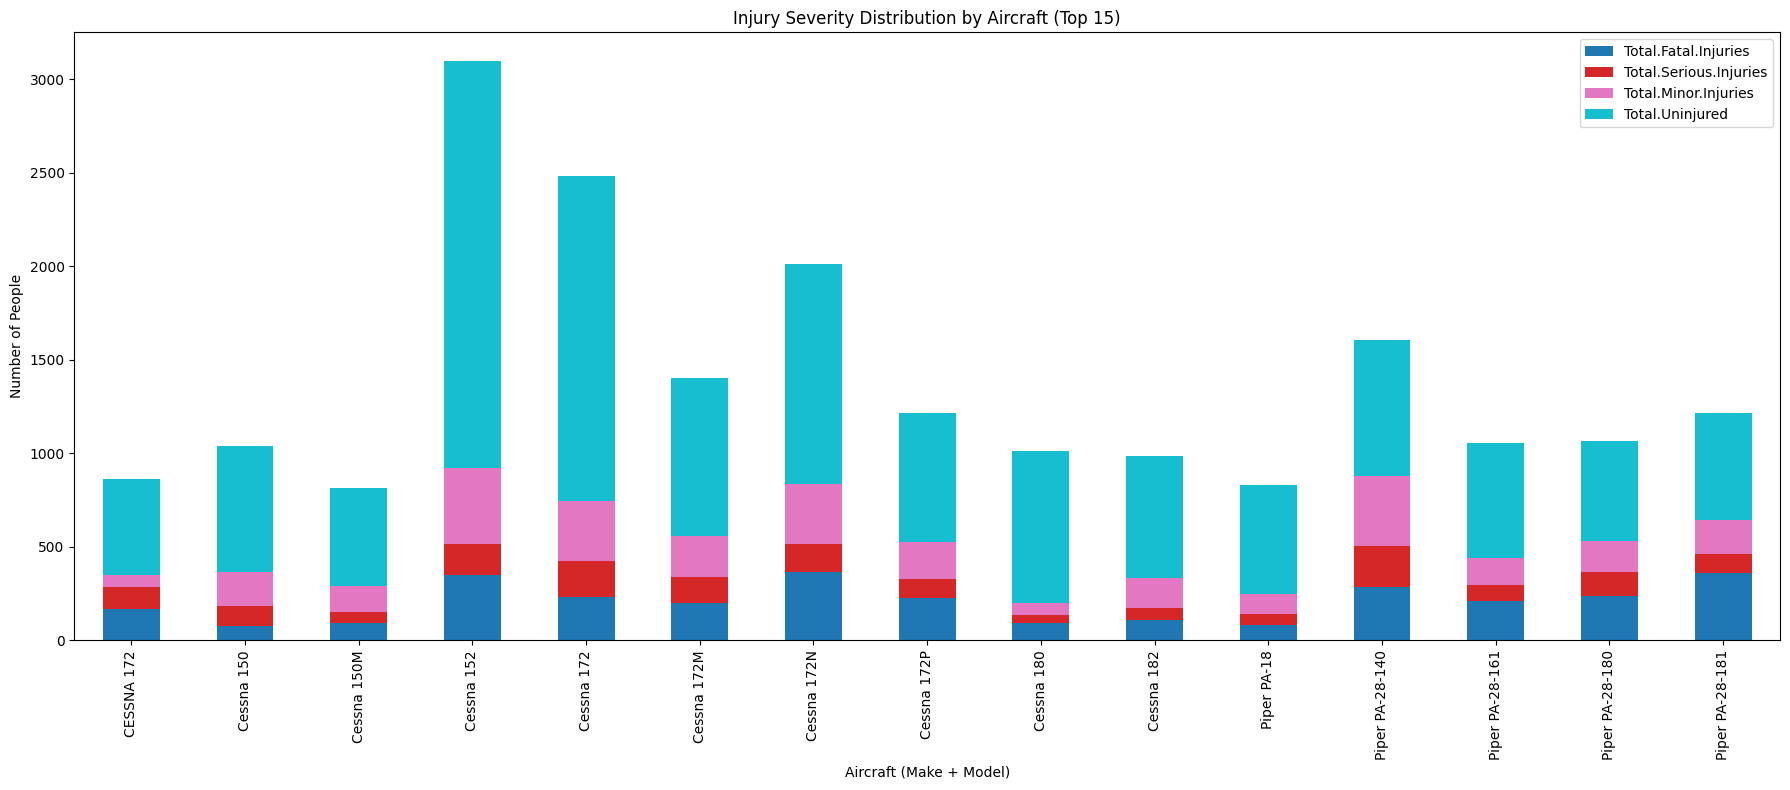

In [30]:
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
injuries = df_filtered.groupby('Make_Model')[injury_cols].sum().reset_index().set_index('Make_Model')

injuries.plot(kind='bar', stacked=True, figsize=(18, 8), colormap='tab10')
plt.title('Injury Severity Distribution by Aircraft (Top 15)')
plt.xlabel('Aircraft (Make + Model)')
plt.ylabel('Number of People')
plt.tight_layout()
plt.show()

/var/folders/4d/l1rvjvyx671bkxht55gt0x1w0000gn/T/ipykernel_70562/3265264932.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aircraft.values, y=top_aircraft.index, palette='Blues_r')


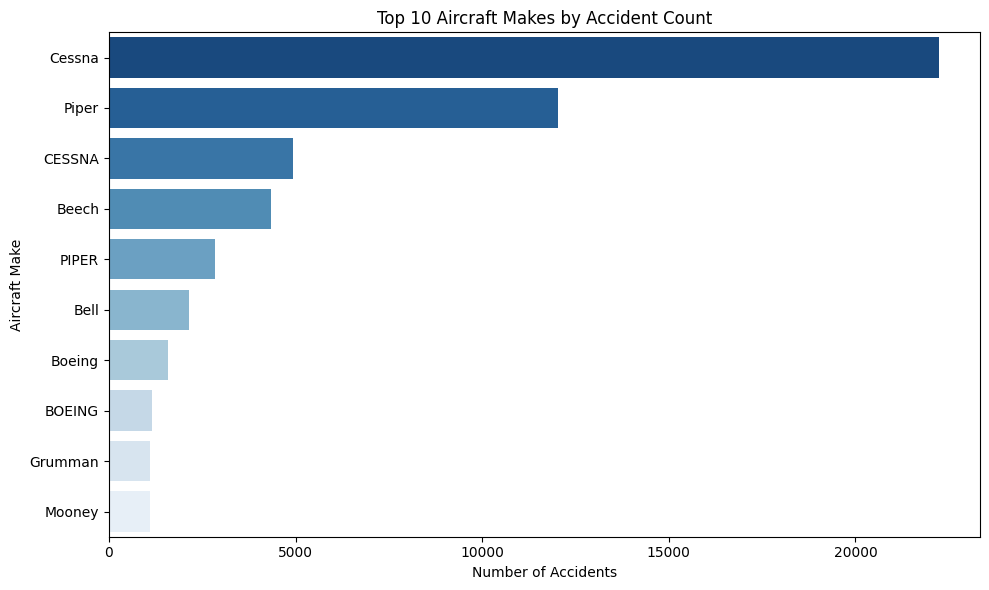

In [28]:
# Aircraft Make vs. Accident Count
# Ensure 'Make' column exists and clean
if 'Make' in df.columns:
    df['Make'] = df['Make'].fillna('Unknown')

    # Get top 10 aircraft makes
    top_aircraft = df['Make'].value_counts().head(10)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_aircraft.values, y=top_aircraft.index, palette='Blues_r')
    plt.title("Top 10 Aircraft Makes by Accident Count")
    plt.xlabel("Number of Accidents")
    plt.ylabel("Aircraft Make")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Make' not found in the dataset.")


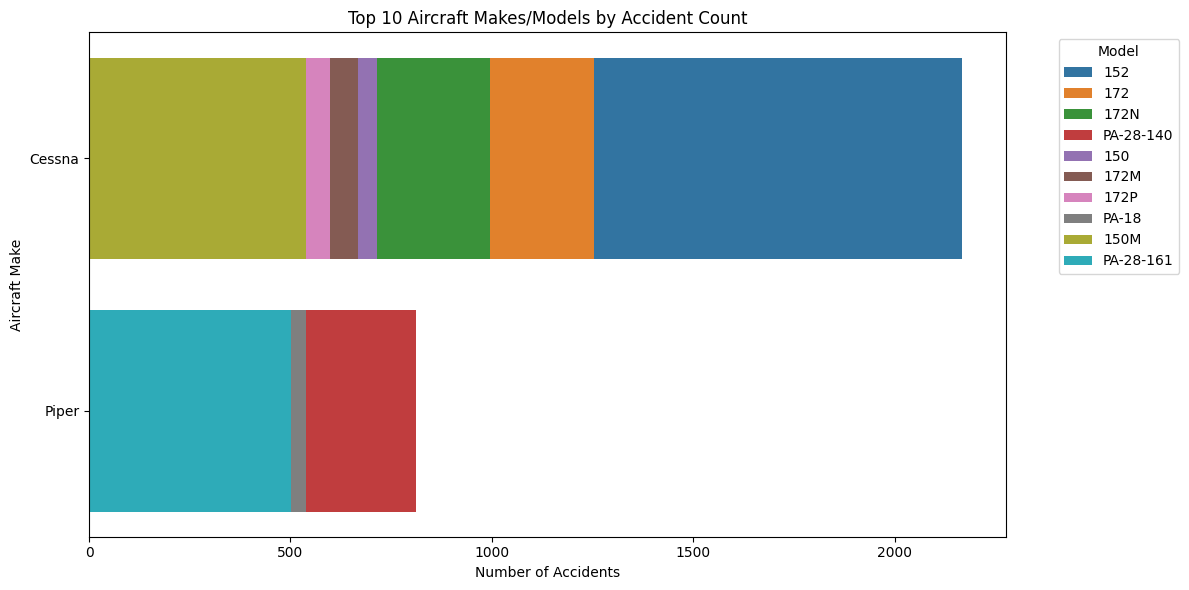

In [29]:
# Group by aircraft Make and Model
accident_freq = df.groupby(['Make', 'Model']).size().reset_index(name='Accident.Count')

# Top 10 aircraft types by accident count
top_aircraft_accidents = accident_freq.sort_values(by='Accident.Count', ascending=False).head(10)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=top_aircraft_accidents, x='Accident.Count', y='Make', hue='Model', dodge=False)
plt.title('Top 10 Aircraft Makes/Models by Accident Count')
plt.xlabel('Number of Accidents')
plt.ylabel('Aircraft Make')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()